10 classes are:


1.   T-shirt/top

1.   Trouser

1.   Pullover

1.   Dress

1.   Coat

1.   Sandal
2.   Shirt


2.   Sneaker


2.   bag


2.   Ankle Boot





In [1]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist
tf.random.set_seed(42)


In [2]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(train_labels)

[9 0 0 ... 3 0 5]


In [4]:
# define classname
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [5]:
print(train_images.shape)

(60000, 28, 28)


In [6]:
print(test_images.shape)

(10000, 28, 28)


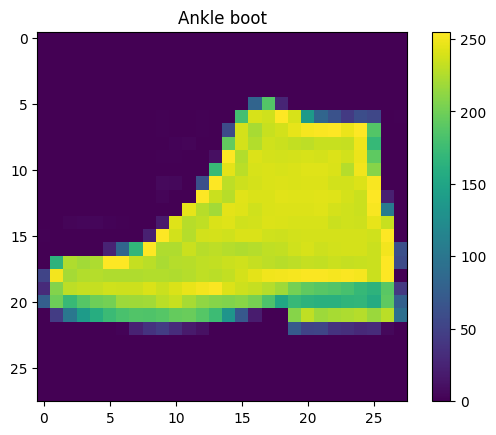

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(train_images[42])
plt.colorbar()
plt.grid(False)
plt.title(class_names[train_labels[42]])
plt.show()

In [8]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0


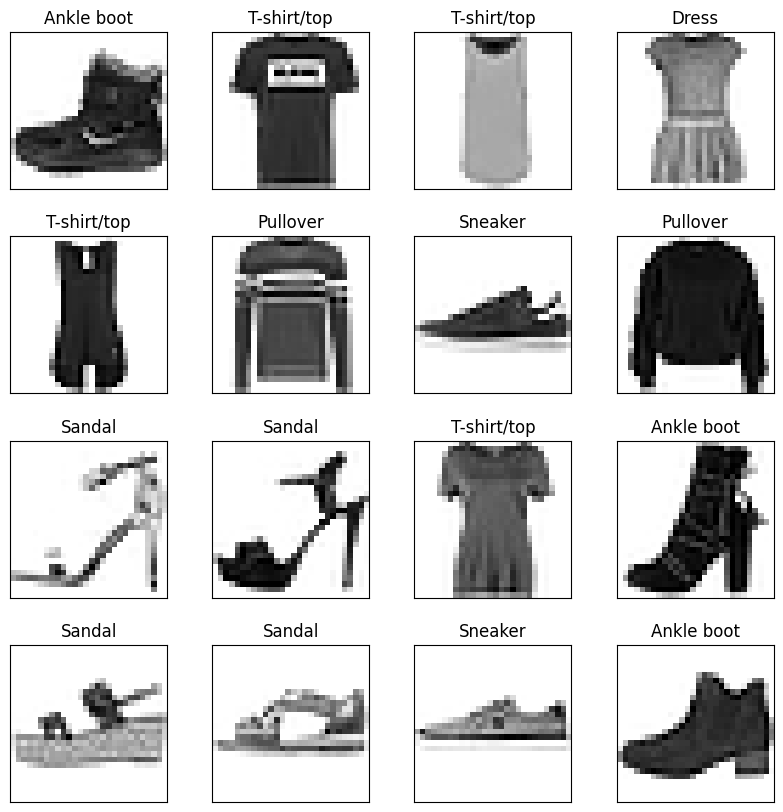

In [9]:
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.subplots_adjust(hspace=.3)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.title(class_names[train_labels[i]])
plt.show()

In [10]:
# we need to reshape the data into 4-dimensions
X_train = train_images.reshape((train_images.shape[0], 28, 28, 1))
X_test = test_images.reshape((test_images.shape[0], 28, 28, 1))
print(X_train.shape)

(60000, 28, 28, 1)


The first dimension is the number of samples


---
The fourth dimension is the appended one representing the grayscale images


In [11]:
from tensorflow.keras import datasets, layers, models, losses

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss=losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,114 (652.79 KB)

 Trainable params: 167,114 (652.79 KB)

 Non-trainable params: 0 (0.00 B)

The benefits of applying pooling are:


1.   avoiding overfitting
2.   Reducing training cost



In [15]:
history_main = model.fit(
    X_train,
    train_labels,
    validation_split=0.15,
    epochs=10,
    batch_size=16,
    shuffle=True
)


Epoch 1/10
3188/3188 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8847 - loss: 0.3170 - val_accuracy: 0.8840 - val_loss: 0.3198
Epoch 2/10
3188/3188 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9070 - loss: 0.2521 - val_accuracy: 0.8864 - val_loss: 0.3112
Epoch 3/10
3188/3188 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9197 - loss: 0.2166 - val_accuracy: 0.8930 - val_loss: 0.3029
Epoch 4/10
3188/3188 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9317 - loss: 0.1872 - val_accuracy: 0.8887 - val_loss: 0.3445
Epoch 5/10
3188/3188 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9395 - loss: 0.1640 - val_accuracy: 0.8930 - val_loss: 0.3606
Epoch 6/10
3188/3188 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9450 - loss: 0.1455 - val_accuracy: 0.8951 - val_loss: 0.3944
Epoch 7/10
3188/3188 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9523 - loss: 0.1276 - val_accuracy: 0.8960 - val_loss: 0.4135
Epoch 8/10
3188/3188 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9552 - loss: 0

In [16]:
test_loss, test_acc = model.evaluate(X_test, test_labels, verbose=2)
print('Accuracy on test set:', test_acc)
print('Test loss:', test_loss)


313/313 - 1s - 3ms/step - accuracy: 0.8968 - loss: 0.4902
Accuracy on test set: 0.8967999815940857
Test loss: 0.4902266561985016


In [17]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [18]:
print(predictions[0])

[1.8923186e-21 9.3111222e-21 5.4726865e-12 1.8403600e-25 1.6107928e-15
 2.3786304e-09 2.7154290e-17 3.9822639e-09 6.0613717e-17 1.0000000e+00]


In [19]:
import numpy as np

print('Predicted label for the first test sample: ', np.argmax(predictions[0]))

Predicted label for the first test sample:  9


In [20]:
print('True label for the first test sample: ', test_labels[0])

True label for the first test sample:  9


In [21]:
def plot_image_prediction(i, images, predictions, labels, class_names):
    plt.subplot(1,2,1)
    plt.imshow(images[i], cmap=plt.cm.binary)
    prediction = np.argmax(predictions[i])
    color = 'blue' if prediction == labels[i] else 'red'
    plt.title(f"{class_names[labels[i]]} (predicted {class_names[prediction]})", color=color)
    plt.subplot(1,2,2)
    plt.grid(False)
    plt.xticks(range(10))
    plot = plt.bar(range(10), predictions[i], color="#777777")
    plt.ylim([0, 1])
    plot[prediction].set_color('red')
    plot[labels[i]].set_color('blue')
    plt.show()

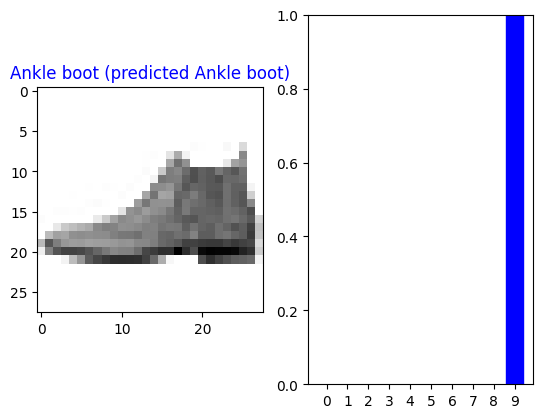

In [22]:
plot_image_prediction(0, test_images, predictions, test_labels, class_names)

In [23]:
model.layers[2].get_weights()[0].shape

(3, 3, 32, 64)

In [24]:
#
filters, _ = model.layers[2].get_weights()
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max-f_min)

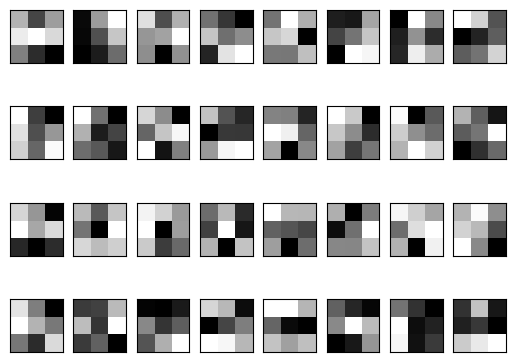

In [25]:
n_filters = 32
for i in range(n_filters):
  filter = filters[:, :, :, i]
  plt.subplot(4, 8, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(filter[:, :, 0], cmap='gray')

plt.show()

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

n_small = 500
X_train_small = X_train[:n_small]
y_train_small = train_labels[:n_small]
print(X_train_small.shape)


(500, 28, 28, 1)


In [27]:
model_small = models.Sequential()
model_small.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model_small.add(layers.MaxPooling2D((2, 2)))
model_small.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_small.add(layers.Flatten())
model_small.add(layers.Dense(32, activation='relu'))
model_small.add(layers.Dense(10, activation='softmax'))


In [28]:
model_small.compile(
    optimizer='adam',
    loss=losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)


In [31]:
history_small = model_small.fit(
    X_train_small,
    y_train_small,
    validation_split=0.15,
    epochs=30,
    batch_size=16,
    shuffle=True
)


Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9412 - loss: 0.1639 - val_accuracy: 0.8267 - val_loss: 0.7541
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9459 - loss: 0.1365 - val_accuracy: 0.8133 - val_loss: 0.8545
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9200 - loss: 0.1920 - val_accuracy: 0.8267 - val_loss: 0.7697
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9624 - loss: 0.1362 - val_accuracy: 0.8133 - val_loss: 0.8572
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9671 - loss: 0.0932 - val_accuracy: 0.8400 - val_loss: 0.7849
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9788 - loss: 0.0929 - val_accuracy: 0.8267 - val_loss: 0.7727
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9835 - loss: 0.0657 - val_accuracy: 0.8667 - val_loss: 0.6916
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9882 - loss: 0.0438 - val_accuracy: 0.8267 - val_loss

In [32]:
test_loss_small, test_acc_small = model_small.evaluate(X_test, test_labels, verbose=2)
print('Small CNN accuracy on test set:', test_acc_small)
print('Small CNN test loss:', test_loss_small)


313/313 - 1s - 2ms/step - accuracy: 0.7918 - loss: 1.3352
Small CNN accuracy on test set: 0.7918000221252441
Small CNN test loss: 1.3352127075195312


The accuracy  without augmentation has a classification accuracy of 79.5%

In [33]:
datagen = ImageDataGenerator(
    height_shift_range=3,
    horizontal_flip=True
)


In [34]:
model_aug = tf.keras.models.clone_model(model_small)


In [35]:
model_aug.compile(
    optimizer='adam',
    loss=losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)


In [37]:
train_generator = datagen.flow(
    X_train_small,
    y_train_small,
    seed=42,
    batch_size=16
)

history_aug = model_aug.fit(
    train_generator,
    epochs=50,
    validation_data=(X_test, test_labels)
)


Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.8540 - loss: 0.4660 - val_accuracy: 0.7010 - val_loss: 0.9721
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8580 - loss: 0.4583 - val_accuracy: 0.7688 - val_loss: 0.7577
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8600 - loss: 0.3977 - val_accuracy: 0.7660 - val_loss: 0.7844
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8920 - loss: 0.3229 - val_accuracy: 0.7649 - val_loss: 0.8394
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8780 - loss: 0.3549 - val_accuracy: 0.7599 - val_loss: 0.8153
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8580 - loss: 0.3919 - val_accuracy: 0.7668 - val_loss: 0.7807
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9060 - loss: 0.3143 - val_accuracy: 0.7766 - val_loss: 0.7893
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9040 - loss: 0.2826 - val_accuracy: 0.7691 - v

In [38]:
test_loss_aug, test_acc_aug = model_aug.evaluate(X_test, test_labels, verbose=2)
print('Augmented CNN accuracy on test set:', test_acc_aug)
print('Augmented CNN test loss:', test_loss_aug)


313/313 - 1s - 2ms/step - accuracy: 0.7778 - loss: 1.5185
Augmented CNN accuracy on test set: 0.7778000235557556
Augmented CNN test loss: 1.5185205936431885


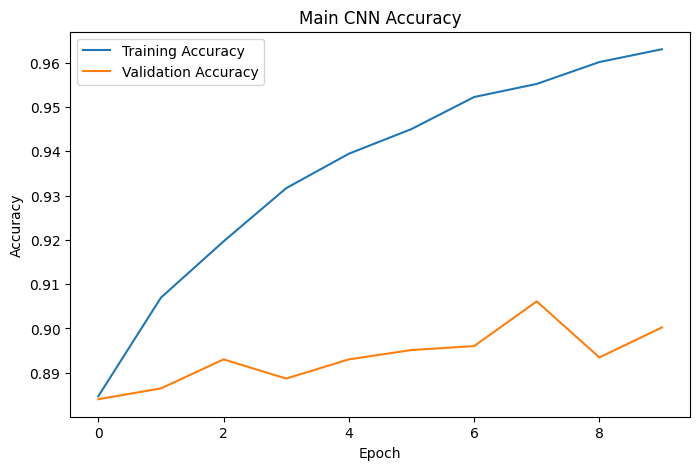

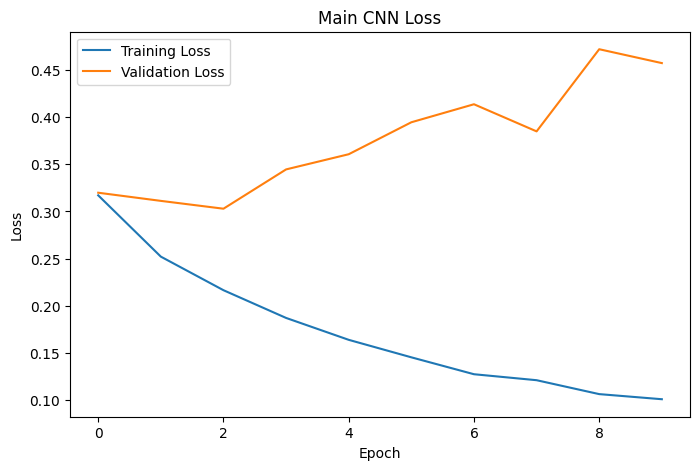

In [39]:
# Main CNN training curves
plt.figure(figsize=(8, 5))
plt.plot(history_main.history['accuracy'], label='Training Accuracy')
plt.plot(history_main.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Main CNN Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_main.history['loss'], label='Training Loss')
plt.plot(history_main.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Main CNN Loss')
plt.legend()
plt.show()


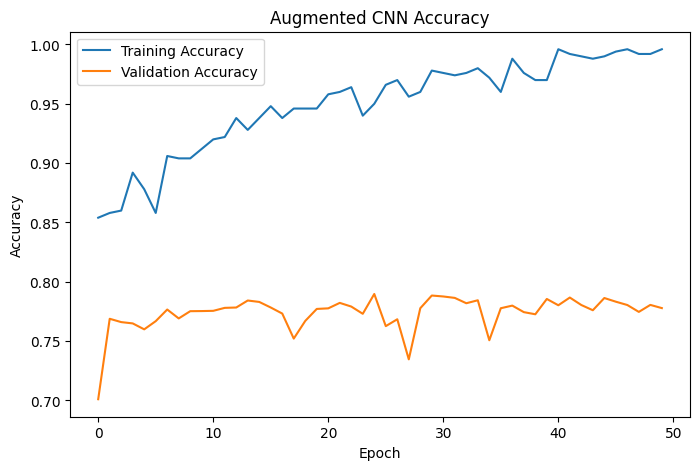

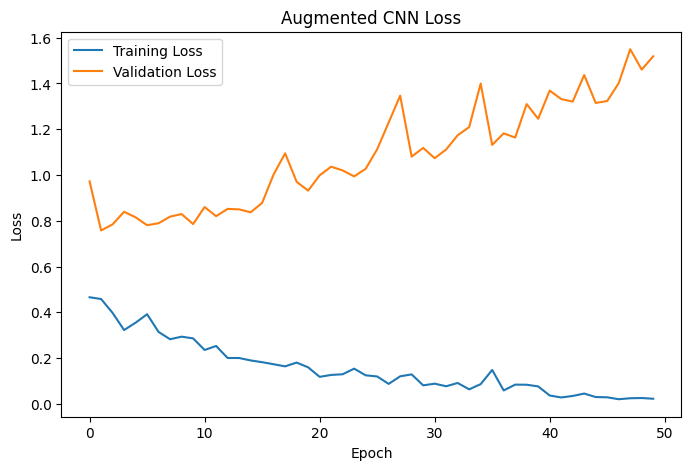

In [40]:
# Augmented CNN training curves
plt.figure(figsize=(8, 5))
plt.plot(history_aug.history['accuracy'], label='Training Accuracy')
plt.plot(history_aug.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Augmented CNN Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_aug.history['loss'], label='Training Loss')
plt.plot(history_aug.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Augmented CNN Loss')
plt.legend()
plt.show()


In [41]:
# Save all trained models
model.save('fashion_mnist_main_cnn.keras')
model_small.save('fashion_mnist_small_cnn.keras')
model_aug.save('fashion_mnist_augmented_cnn.keras')

print('Saved models:')
print('fashion_mnist_main_cnn.keras')
print('fashion_mnist_small_cnn.keras')
print('fashion_mnist_augmented_cnn.keras')


Saved models:
fashion_mnist_main_cnn.keras
fashion_mnist_small_cnn.keras
fashion_mnist_augmented_cnn.keras


In [42]:
# Optional: save model weights as backups
model.save_weights('fashion_mnist_main_cnn.weights.h5')
model_small.save_weights('fashion_mnist_small_cnn.weights.h5')
model_aug.save_weights('fashion_mnist_augmented_cnn.weights.h5')

print('Weights saved successfully.')


Weights saved successfully.


In [43]:
# Download the final augmented model to your computer (Google Colab)
from google.colab import files
files.download('fashion_mnist_augmented_cnn.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>